# OME-Arrow and CytoDataFrame

This notebook demonstrates how [OME-Arrow](https://github.com/WayScience/ome-arrow) works in context with CytoDataFrame.

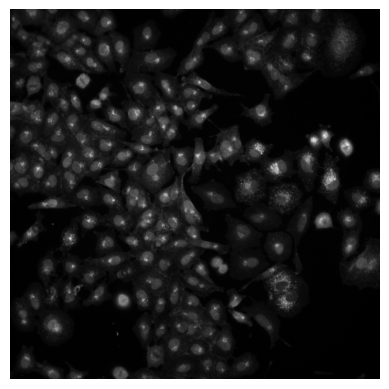

In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
from ome_arrow import OMEArrow

from cytodataframe import CytoDataFrame

# load a tiff using OME Arrow
oa_img = OMEArrow(
    "../../../tests/data/cytotable/JUMP_plate_BR00117006/images/orig/r01c01f01p01-ch2sk1fk1fl1.tiff"
)
oa_img

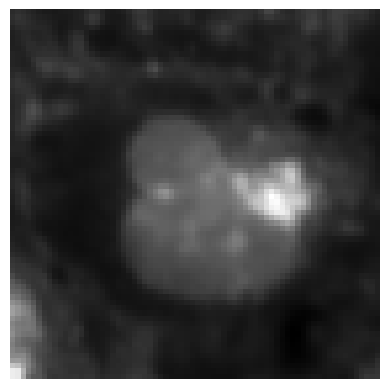

In [2]:
# make a "slice" (crop) from the overall image
oa_img_slice = oa_img.slice(x_min=240, x_max=310, y_min=360, y_max=430)
oa_img_slice

In [3]:
# show the OME Arrow struct
oa_img_slice.data

<pyarrow.StructScalar: [('type', 'ome.arrow'), ('version', '0.0.4'), ('id', 'r01c01f01p01-ch2sk1fk1fl1'), ('name', 'r01c01f01p01-ch2sk1fk1fl1.tiff'), ('acquisition_datetime', datetime.datetime(2026, 4, 15, 20, 24, 10, 45209)), ('pixels_meta', {'dimension_order': 'XYCT', 'type': 'uint16', 'size_x': 70, 'size_y': 70, 'size_z': 1, 'size_c': 1, 'size_t': 1, 'physical_size_x': 6.450363636016846, 'physical_size_y': 6.450363636016846, 'physical_size_z': 1.0, 'physical_size_x_unit': 'µm', 'physical_size_y_unit': 'µm', 'physical_size_z_unit': 'µm', 'channels': [{'id': 'ch-0', 'name': 'C0', 'emission_um': 0.0, 'excitation_um': 0.0, 'illumination': 'Unknown', 'color_rgba': 4294967295}]}), ('planes', [{'z': 0, 't': 0, 'c': 0, 'pixels': [5772, 6209, 5847, 5408, 4959, 4513, 4232, 4181, 4020, 4196, 4264, 4454, 4718, 4916, 5663, 6358, 6160, 5144, 4283, 4093, 4270, 4760, 5641, 6585, 7169, 7073, 6220, 5362, 5038, 5063, 5343, 5341, 5645, 5735, 4975, 4504, 4532, 4712, 5094, 5362, 5527, 5934, 6132, 6384, 6

,metadata_1,feature_1,image
0,0,1,
1,2,2,

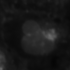
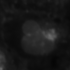

In [4]:
# create a pyarrow table for writing the data
table = pa.table(
    {
        # two columns, two values each, both int64 type
        "metadata_1": pa.array([0, 2], type=pa.int64()),
        "feature_1": pa.array([1, 2], type=pa.int64()),
        # add an image column with repeated entries based on the image slice
        "image": pa.repeat(oa_img_slice.data, 2),
    }
)

# write a parquet table
pq.write_table(table, "example.ome.parquet")

# read the parquet table with cytodataframe
# (showing the OME-Arrow image that was written)
CytoDataFrame("example.ome.parquet")